In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

/tmp/ipykernel_202595/3632437423.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
#!/usr/bin/env python3
from pathlib import Path
import pandas as pd

BASE = Path.home() / "scratch/pang/pang_experiment_ref"
PANG_DIR = BASE / "pangenomes"
OUT = BASE / "pangenome_graph_sizes_mb.tsv"

def first_existing(candidates):
    for p in candidates:
        if p.exists() and p.is_file() and p.stat().st_size > 0:
            return p
    return None

rows = []

for setdir in sorted(PANG_DIR.glob("set_*")):
    if not setdir.is_dir():
        continue

    setname = setdir.name
    outdir = setdir / "output"
    if not outdir.exists():
        continue

    # Prefer d2.gbz (the one you typically map with), else fall back to .gbz
    gbz = first_existing([
        outdir / f"{setname}.d2.gbz",
        outdir / f"{setname}.gbz",
    ])
    if gbz is None:
        continue

    size_bytes = gbz.stat().st_size
    size_mb = size_bytes / (1024 * 1024)

    rows.append({
        "set": setname,
        "gbz_path": str(gbz),
        "gbz_size_mb": round(size_mb, 3),
    })

df = pd.DataFrame(rows)
if not df.empty:
    df = df.sort_values("gbz_size_mb", ascending=False)



In [3]:
#!/usr/bin/env python3
from pathlib import Path
import re
import pandas as pd

BASE = Path.home() / "scratch/pang/pang_experiment_ref"
PANG_DIR = BASE / "pangenomes"
LOG_DIR = BASE / "scripts"   # where your set_02_rep1.754.err lives
OUT = BASE / "pangenome_graph_sizes_mb.tsv"

RUNTIME_RE = re.compile(r"cactus-pangenome has finished after ([0-9.]+) seconds")

def first_existing(candidates):
    for p in candidates:
        if p.exists() and p.is_file() and p.stat().st_size > 0:
            return p
    return None

def parse_runtime_seconds(err_path: Path):
    """Return float seconds if found, else None."""
    try:
        # Search from the end (runtime is near the bottom)
        with err_path.open("r", errors="ignore") as f:
            lines = f.readlines()
        for line in reversed(lines[-2000:]):  # last chunk is enough
            m = RUNTIME_RE.search(line)
            if m:
                return float(m.group(1))
    except FileNotFoundError:
        return None
    return None

rows = []

for setdir in sorted(PANG_DIR.glob("set_*")):
    if not setdir.is_dir():
        continue

    setname = setdir.name
    outdir = setdir / "output"
    if not outdir.exists():
        continue

    # Prefer d2.gbz, else .gbz
    gbz = first_existing([
        outdir / f"{setname}.d2.gbz",
        outdir / f"{setname}.gbz",
    ])
    if gbz is None:
        continue

    size_mb = gbz.stat().st_size / (1024 * 1024)

    # Find the corresponding cactus stderr log: e.g. set_02_rep1.754.err
    err_candidates = sorted(LOG_DIR.glob(f"{setname}.*.err"))
    err_path = err_candidates[0] if err_candidates else None
    runtime_s = parse_runtime_seconds(err_path) if err_path else None

    rows.append({
        "set": setname,
        "gbz_size_mb": round(size_mb, 3),
        "runtime_seconds": runtime_s,
        "runtime_hours": (runtime_s / 3600.0) if runtime_s is not None else None,
        "err_log": str(err_path) if err_path else None,
    })

df = pd.DataFrame(rows)

# nice sorting: by size descending
if not df.empty:
    df = df.sort_values("gbz_size_mb", ascending=False)

In [4]:
df

,set,gbz_size_mb,runtime_seconds,runtime_hours,err_log
12,set_all_rep1,659.377,144471.216617,40.130894,/home/tbellagio/scratch/pang/pang_experiment_r...
11,set_18_rep3,339.671,24700.780971,6.861328,/home/tbellagio/scratch/pang/pang_experiment_r...
10,set_18_rep2,339.602,24280.529417,6.744592,/home/tbellagio/scratch/pang/pang_experiment_r...
9,set_18_rep1,339.591,25004.385284,6.945663,/home/tbellagio/scratch/pang/pang_experiment_r...
6,set_10_rep1,272.952,11137.416562,3.093727,/home/tbellagio/scratch/pang/pang_experiment_r...
8,set_10_rep3,265.929,10475.133194,2.909759,/home/tbellagio/scratch/pang/pang_experiment_r...
7,set_10_rep2,265.847,9607.255803,2.668682,/home/tbellagio/scratch/pang/pang_experiment_r...
3,set_05_rep1,199.913,5304.144873,1.473374,/home/tbellagio/scratch/pang/pang_experiment_r...
5,set_05_rep3,197.594,5634.831698,1.565231,/home/tbellagio/scratch/pang/pang_experiment_r...
4,set_05_rep2,197.144,6916.561421,1.921267,/home/tbellagio/scratch/pang/pang_experiment_r...


In [5]:
import pandas as pd

# df has: set, gbz_path, gbz_size_mb
tmp = df["set"].str.extract(r"^set_(?P<set_size>[^_]+)_rep(?P<rep>\d+)$")
df2 = df.join(tmp)

df2["rep"] = df2["rep"].astype(int)
df2["n_genomes"] = pd.to_numeric(df2["set_size"], errors="coerce")
df2.loc[df2["set_size"] == "all", "n_genomes"] = 69
df2["n_genomes"] = df2["n_genomes"].astype(int)

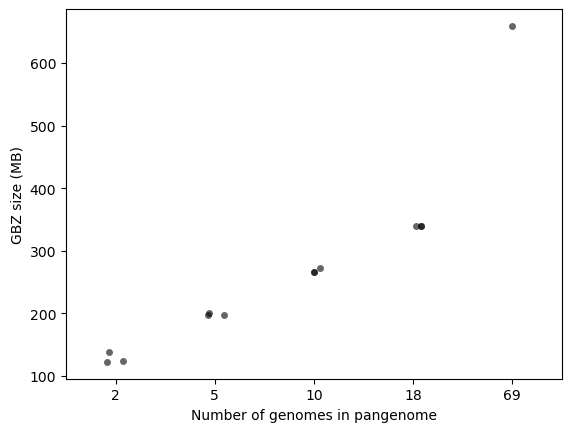

In [6]:

sns.stripplot(
    data=df2,
    x="n_genomes",
    y="gbz_size_mb",
    color="black",
    alpha=0.6
)

plt.xlabel("Number of genomes in pangenome")
plt.ylabel("GBZ size (MB)")
plt.savefig('pangenome_size.png')
plt.show()


In [7]:
df2

,set,gbz_size_mb,runtime_seconds,runtime_hours,err_log,set_size,rep,n_genomes
12,set_all_rep1,659.377,144471.216617,40.130894,/home/tbellagio/scratch/pang/pang_experiment_r...,all,1,69
11,set_18_rep3,339.671,24700.780971,6.861328,/home/tbellagio/scratch/pang/pang_experiment_r...,18,3,18
10,set_18_rep2,339.602,24280.529417,6.744592,/home/tbellagio/scratch/pang/pang_experiment_r...,18,2,18
9,set_18_rep1,339.591,25004.385284,6.945663,/home/tbellagio/scratch/pang/pang_experiment_r...,18,1,18
6,set_10_rep1,272.952,11137.416562,3.093727,/home/tbellagio/scratch/pang/pang_experiment_r...,10,1,10
8,set_10_rep3,265.929,10475.133194,2.909759,/home/tbellagio/scratch/pang/pang_experiment_r...,10,3,10
7,set_10_rep2,265.847,9607.255803,2.668682,/home/tbellagio/scratch/pang/pang_experiment_r...,10,2,10
3,set_05_rep1,199.913,5304.144873,1.473374,/home/tbellagio/scratch/pang/pang_experiment_r...,05,1,5
5,set_05_rep3,197.594,5634.831698,1.565231,/home/tbellagio/scratch/pang/pang_experiment_r...,05,3,5
4,set_05_rep2,197.144,6916.561421,1.921267,/home/tbellagio/scratch/pang/pang_experiment_r...,05,2,5


In [8]:
df2.to_csv('pangenome_sizes_n_runtimes.tsv', sep = '\t')

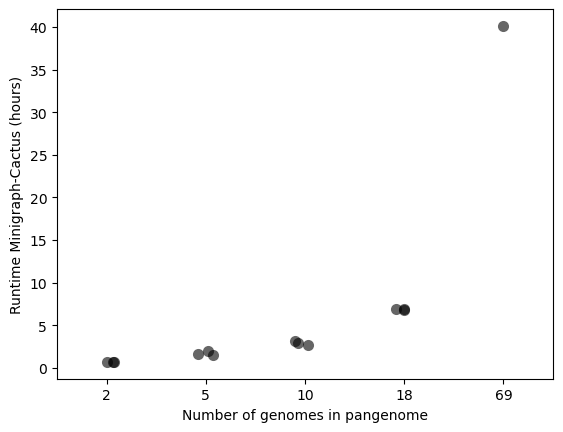

In [9]:
sns.stripplot(
    data=df2,
    x="n_genomes",
    y="runtime_hours",
    color="black",
    s = 8,
    alpha=0.6
)

plt.xlabel("Number of genomes in pangenome")
plt.ylabel("Runtime Minigraph-Cactus (hours)")
plt.savefig('pangenome_run_time.png')
plt.show()

In [10]:
def parse_flagstat(flagstat_file):
    metrics = {}
    with open(flagstat_file) as f:
        for line in f:
            if "in total" in line:
                metrics["total_reads"] = int(line.split()[0])
            elif "mapped (" in line:
                metrics["mapped_reads"] = int(line.split()[0])
            elif "properly paired" in line:
                metrics["properly_paired"] = int(line.split()[0])
    return metrics


In [11]:
def parse_samtools_stats(stats_file):
    metrics = {}
    with open(stats_file) as f:
        for line in f:
            if line.startswith("SN\taverage quality:"):
                metrics["mean_mapq"] = float(line.strip().split()[-1])
    return metrics


In [12]:
from pathlib import Path
import re
from datetime import datetime

DT_FMT = "%a %b %d %I:%M:%S %p %Z %Y"
DT_LINE_RE = re.compile(
    r"^(Mon|Tue|Wed|Thu|Fri|Sat|Sun)\s+[A-Z][a-z]{2}\s+\d{1,2}\s+\d{1,2}:\d{2}:\d{2}\s+(AM|PM)\s+\S+\s+\d{4}$"
)

def parse_linear_runtime_from_logs(
    sample: str,
    logs_dir: Path,
    samples_txt: Path,
    prefer_latest_jobid: bool = True,
):
    """
    Parse runtime for a linear mapping sample from Slurm array .out logs.

    Assumes logs look like:
      logs/MAP_LINEAR_<jobid>_<taskid>.out

    And samples_txt contains one sample per line (array index is 1-based).

    Returns dict with:
      runtime_seconds, runtime_minutes, runtime_hours, runtime_start, runtime_end, runtime_log
    Missing values -> None.
    """
    if not samples_txt.exists():
        return {
            "runtime_seconds": None,
            "runtime_minutes": None,
            "runtime_hours": None,
            "runtime_start": None,
            "runtime_end": None,
            "runtime_log": None,
        }

    # taskid = 1-based line number where sample appears in samples.txt
    samples = [l.strip() for l in samples_txt.read_text().splitlines() if l.strip()]
    try:
        taskid = samples.index(sample) + 1
    except ValueError:
        taskid = None

    if taskid is None:
        return {
            "runtime_seconds": None,
            "runtime_minutes": None,
            "runtime_hours": None,
            "runtime_start": None,
            "runtime_end": None,
            "runtime_log": None,
        }

    # Find matching logs for this taskid
    # e.g. MAP_LINEAR_807_1.out
    candidates = list(logs_dir.glob(f"MAP_LINEAR_*_{taskid}.out"))
    if not candidates:
        return {
            "runtime_seconds": None,
            "runtime_minutes": None,
            "runtime_hours": None,
            "runtime_start": None,
            "runtime_end": None,
            "runtime_log": None,
        }

    # If multiple jobids exist, choose latest by mtime (or smallest jobid if you prefer)
    if prefer_latest_jobid:
        outlog = max(candidates, key=lambda p: p.stat().st_mtime)
    else:
        # pick lowest jobid
        def jobid(p):
            m = re.search(r"MAP_LINEAR_(\d+)_\d+\.out$", p.name)
            return int(m.group(1)) if m else 0
        outlog = min(candidates, key=jobid)

    # Parse timestamps: first date line = start, last date line = end
    lines = outlog.read_text(errors="ignore").splitlines()
    dt_lines = [l.strip() for l in lines if DT_LINE_RE.match(l.strip())]

    if len(dt_lines) < 2:
        return {
            "runtime_seconds": None,
            "runtime_minutes": None,
            "runtime_hours": None,
            "runtime_start": None,
            "runtime_end": None,
            "runtime_log": str(outlog),
        }

    start_dt = datetime.strptime(dt_lines[0], DT_FMT)
    end_dt = datetime.strptime(dt_lines[-1], DT_FMT)
    runtime_s = (end_dt - start_dt).total_seconds()

    return {
        "runtime_seconds": runtime_s,
        "runtime_minutes": runtime_s / 60.0,
        "runtime_hours": runtime_s / 3600.0,
        "runtime_start": start_dt.strftime("%Y-%m-%d %H:%M:%S"),
        "runtime_end": end_dt.strftime("%Y-%m-%d %H:%M:%S"),
        "runtime_log": str(outlog),
    }


In [13]:
LINEAR_LOGS = Path.home() / "scratch/pang/pang_experiment_ref/linear_mapping/logs"
LINEAR_SAMPLES_TXT = Path.home() / "scratch/pang/pang_experiment_ref/linear_mapping/samples.txt"

In [14]:
from pathlib import Path
import re
import pandas as pd

LINEAR_BASE = Path.home() / "scratch/pang/pang_experiment_ref/linear_mapping/results"


rows_linear = []

for sample_dir in LINEAR_BASE.iterdir():
    if not sample_dir.is_dir():
        continue

    sample = sample_dir.name

    flagstat = sample_dir / f"{sample}.flagstat.txt"
    stats = sample_dir / f"{sample}.stats.txt"

    if not flagstat.exists():
        continue

    lin_stats = parse_flagstat(flagstat)
    lin_stats.update(
    parse_linear_runtime_from_logs(
        sample=sample,
        logs_dir=LINEAR_LOGS,
        samples_txt=LINEAR_SAMPLES_TXT,
    )
    )
    
    if stats.exists():
        lin_stats.update(parse_samtools_stats(stats))

    lin_stats["pct_mapped"] = (
        lin_stats["mapped_reads"] / lin_stats["total_reads"]
    )

    lin_stats["pct_properly_paired"] = (
        lin_stats["properly_paired"] / lin_stats["total_reads"]
    )

    rows_linear.append({
        "method": "linear",
        "set": "TAIR10",
        "rep": "NA",
        "sample": sample,
        "n_genomes": 1,
        **lin_stats
    })


In [15]:
linear_stats = pd.DataFrame(rows_linear)

In [16]:
total_reads = linear_stats[['sample', 'total_reads']].copy()

In [17]:
1925.31/60

32.088499999999996

In [18]:
60 * 0.7

42.0

In [19]:
linear_stats

,method,set,rep,sample,n_genomes,total_reads,mapped_reads,properly_paired,runtime_seconds,runtime_minutes,runtime_hours,runtime_start,runtime_end,runtime_log,mean_mapq,pct_mapped,pct_properly_paired
0,linear,TAIR10,NA,S3,1,54663613,53815648,50991142,1783.0,29.716667,0.495278,2026-01-26 10:06:19,2026-01-26 10:36:02,/home/tbellagio/scratch/pang/pang_experiment_r...,39.0,0.984488,0.932817
1,linear,TAIR10,NA,S4,1,59147188,58318250,51873358,1968.0,32.800000,0.546667,2026-01-26 10:06:19,2026-01-26 10:39:07,/home/tbellagio/scratch/pang/pang_experiment_r...,39.0,0.985985,0.877022
2,linear,TAIR10,NA,S7,1,65470750,64565548,59305416,2119.0,35.316667,0.588611,2026-01-26 10:36:03,2026-01-26 11:11:22,/home/tbellagio/scratch/pang/pang_experiment_r...,39.0,0.986174,0.905831
3,linear,TAIR10,NA,S5,1,68300598,67378726,61754390,2228.0,37.133333,0.618889,2026-01-26 10:06:19,2026-01-26 10:43:27,/home/tbellagio/scratch/pang/pang_experiment_r...,39.1,0.986503,0.904156
4,linear,TAIR10,NA,S2,1,50837751,50080257,46409188,1672.0,27.866667,0.464444,2026-01-26 10:06:19,2026-01-26 10:34:11,/home/tbellagio/scratch/pang/pang_experiment_r...,38.9,0.985100,0.912888
5,linear,TAIR10,NA,S8,1,74608197,73590763,65772784,2476.0,41.266667,0.687778,2026-01-26 10:39:08,2026-01-26 11:20:24,/home/tbellagio/scratch/pang/pang_experiment_r...,39.0,0.986363,0.881576
6,linear,TAIR10,NA,S6,1,70911561,69566682,62554918,2347.0,39.116667,0.651944,2026-01-26 10:34:12,2026-01-26 11:13:19,/home/tbellagio/scratch/pang/pang_experiment_r...,39.0,0.981034,0.882154
7,linear,TAIR10,NA,S1,1,78818808,76304172,71465104,2535.0,42.250000,0.704167,2026-01-26 10:06:19,2026-01-26 10:48:34,/home/tbellagio/scratch/pang/pang_experiment_r...,39.0,0.968096,0.906701


In [20]:
import re
from pathlib import Path
import pandas as pd

In [21]:
from pathlib import Path
import re
from datetime import datetime

ISO_TS_RE = re.compile(r"\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}(?:[+-]\d{2}:\d{2})?")

def parse_pangenome_mapping_runtime_from_logs(
    set_name: str,
    sample: str,
    logs_dir: Path,
    prefer_latest: bool = True,
):
    """
    Parse runtime for vg giraffe mapping from Slurm .out logs like:
      logs/map_<set_name>_<sample>.<jobid>.out
    Example contents:
      ▶ START 2026-01-27T09:20:21-08:00
      ▶ END   2026-01-27T10:51:31-08:00
      ▶ RUNTIME_SECONDS 5470

    Returns dict with:
      vg_runtime_seconds, vg_runtime_minutes, vg_runtime_hours,
      vg_start, vg_end, vg_log

    Missing values -> None.
    """
    pattern = f"map_{set_name}_{sample}.*.out"
    candidates = list(logs_dir.glob(pattern))
    if not candidates:
        # sometimes logs might live elsewhere; return empty
        return {
            "vg_runtime_seconds": None,
            "vg_runtime_minutes": None,
            "vg_runtime_hours": None,
            "vg_start": None,
            "vg_end": None,
            "vg_log": None,
        }

    outlog = max(candidates, key=lambda p: p.stat().st_mtime) if prefer_latest else candidates[0]

    start_iso = None
    end_iso = None
    runtime_s = None

    for line in outlog.read_text(errors="ignore").splitlines():
        line = line.strip()
        if "RUNTIME_SECONDS" in line:
            # e.g. "▶ RUNTIME_SECONDS 5470"
            parts = line.split()
            # last token should be the number
            try:
                runtime_s = float(parts[-1])
            except Exception:
                pass
        elif line.startswith("▶ START"):
            m = ISO_TS_RE.search(line)
            if m:
                start_iso = m.group(0)
        elif line.startswith("▶ END"):
            m = ISO_TS_RE.search(line)
            if m:
                end_iso = m.group(0)

    # If runtime wasn't printed, compute from timestamps (if present)
    if runtime_s is None and start_iso and end_iso:
        try:
            sdt = datetime.fromisoformat(start_iso)
            edt = datetime.fromisoformat(end_iso)
            runtime_s = (edt - sdt).total_seconds()
        except Exception:
            runtime_s = None

    return {
        "runtime_seconds": runtime_s,
        "runtime_minutes": (runtime_s / 60.0) if runtime_s is not None else None,
        "runtime_hours": (runtime_s / 3600.0) if runtime_s is not None else None,
        "start": start_iso,
        "end": end_iso,
        "log": str(outlog),
    }


In [22]:
SCRIPTS_LOGDIR = Path.home() / "scratch/pang/pang_experiment_ref/scripts"


In [23]:
BASE = Path.home() / "scratch/pang/pang_experiment_ref/pangenomes"

def parse_vg_stats(stats_file):
    metrics = {}
    with open(stats_file) as f:
        for line in f:
            line = line.strip()

            if line.startswith("Total alignments:"):
                metrics["total_reads_nosupp"] = int(line.split(":")[1])

            elif line.startswith("Total aligned:"):
                metrics["mapped_reads"] = int(line.split(":")[1])

            elif line.startswith("Total properly paired:"):
                metrics["properly_paired"] = int(line.split(":")[1])

            elif line.startswith("Mapping quality:"):
                m = re.search(r"mean ([\d\.]+), median (\d+)", line)
                if m:
                    metrics["mean_mapq"] = float(m.group(1))
                    metrics["median_mapq"] = int(m.group(2))

            elif line.startswith("Total time:"):
                # example: "Total time: 63599.7 seconds"
                metrics["mapping_time_sec"] = float(
                    line.replace("Total time:", "")
                        .replace("seconds", "")
                        .strip()
                )

            elif line.startswith("Speed:"):
                # example: "Speed: 1230.19 reads/second"
                metrics["reads_per_sec"] = float(
                    line.split()[1]
                )
            elif line.startswith("Total perfect:"):
                metrics["perfect_reads"] = int(line.split(":")[1])

            elif line.startswith("Total gapless"):
                metrics["gapless_reads"] = int(line.split(":")[1])


    return metrics



rows = []

for set_dir in BASE.glob("set_*_rep*"):
    set_name = set_dir.name              # set_10_rep2
    set_label = "_".join(set_name.split("_")[:2])  # set_10
    rep = set_name.split("_")[2]         # rep2

    # infer number of genomes
    n_lookup = {
        "set_02": 2,
        "set_05": 5,
        "set_10": 10,
        "set_15": 15,
        "set_18": 18,
        "set_50": 50,
        "set_all": 69
    }
    n_genomes = n_lookup.get(set_label)

    mapping_dir = set_dir / "mapping" / "seedmix"
    if not mapping_dir.exists():
        continue

    for sample_dir in mapping_dir.iterdir():
        if not sample_dir.is_dir():
            continue

        stats_file = sample_dir / f"{sample_dir.name}.stats.txt"
        if not stats_file.exists():
            continue

        stats = parse_vg_stats(stats_file)

        stats.update(
            parse_pangenome_mapping_runtime_from_logs(
                set_name=set_name,                 # IMPORTANT: full name like set_10_rep3
                sample=sample_dir.name,            # S7
                logs_dir=SCRIPTS_LOGDIR,
            )
        )


        #if "total_reads" not in stats:
        #    continue

        #stats["pct_mapped"] = stats["mapped_reads"] / stats["total_reads"]
        #stats["pct_perfect"] = stats["perfect_reads"] / stats["total_reads"]
        #stats["pct_gapless"] = stats["gapless_reads"] / stats["total_reads"]
    

        rows.append({
            "set": set_label,
            "rep": rep,
            "sample": sample_dir.name,
            "n_genomes": n_genomes,
            **stats
        })


In [24]:
df_map = pd.DataFrame(rows)

In [33]:
df_map

,set,rep,sample,n_genomes,total_reads_nosupp,mapped_reads,perfect_reads,gapless_reads,properly_paired,mean_mapq,...,runtime_minutes,runtime_hours,start,end,log,total_reads,pct_properly_paired,pct_mapped,pct_perfect,pct_gapless
0,set_02,rep1,S1,2,78239732,74019223,40995783,68445989,73591874,43.3844,...,40.516667,0.675278,2026-01-26T19:23:10-08:00,2026-01-26T20:03:41-08:00,/home/tbellagio/scratch/pang/pang_experiment_r...,78818808,0.933684,0.939106,0.520127,0.868397
1,set_02,rep1,S2,2,50474180,48362310,26607382,44762431,47949728,43.1068,...,27.433333,0.457222,2026-01-26T19:23:09-08:00,2026-01-26T19:50:35-08:00,/home/tbellagio/scratch/pang/pang_experiment_r...,50837751,0.943191,0.951307,0.523378,0.880496
2,set_02,rep1,S3,2,54308174,52448391,28827283,48431671,52234208,43.6210,...,27.933333,0.465556,2026-01-26T19:53:07-08:00,2026-01-26T20:21:03-08:00,/home/tbellagio/scratch/pang/pang_experiment_r...,54663613,0.955557,0.959475,0.527358,0.885995
3,set_02,rep1,S4,2,58646998,55377031,30556174,51287491,54445038,42.5012,...,33.350000,0.555833,2026-01-26T20:07:38-08:00,2026-01-26T20:40:59-08:00,/home/tbellagio/scratch/pang/pang_experiment_r...,59147188,0.920501,0.936258,0.516612,0.867116
4,set_02,rep1,S5,2,67755386,64753981,35913935,59890069,64061150,42.8888,...,36.266667,0.604444,2026-01-26T20:23:50-08:00,2026-01-26T21:00:06-08:00,/home/tbellagio/scratch/pang/pang_experiment_r...,68300598,0.937930,0.948073,0.525822,0.876860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,set_18,rep2,S3,18,54308174,53321610,36542901,51556167,52999300,43.2183,...,120.116667,2.001944,2026-01-27T14:52:34-08:00,2026-01-27T16:52:41-08:00,/home/tbellagio/scratch/pang/pang_experiment_r...,54663613,0.969554,0.975450,0.668505,0.943153
82,set_18,rep2,S4,18,58646998,56264081,38298143,54420065,55020528,41.9697,...,134.183333,2.236389,2026-01-27T15:14:21-08:00,2026-01-27T17:28:32-08:00,/home/tbellagio/scratch/pang/pang_experiment_r...,59147188,0.930231,0.951255,0.647506,0.920079
83,set_18,rep2,S5,18,67755386,65783174,44965243,63571337,64854534,42.3619,...,150.983333,2.516389,2026-01-27T16:01:11-08:00,2026-01-27T18:32:10-08:00,/home/tbellagio/scratch/pang/pang_experiment_r...,68300598,0.949546,0.963142,0.658343,0.930758
84,set_18,rep2,S6,18,70309590,67445458,45876519,65201929,66203884,42.3489,...,156.633333,2.610556,2026-01-27T16:02:29-08:00,2026-01-27T18:39:07-08:00,/home/tbellagio/scratch/pang/pang_experiment_r...,70911561,0.933612,0.951121,0.646954,0.919482


In [25]:
df_map.sort_values(["n_genomes", "rep", "sample"], inplace=True)
df_map.reset_index(drop=True, inplace=True)

In [26]:
df_map = df_map.merge(total_reads, on ='sample')

In [27]:
df_map["pct_properly_paired"]  = df_map['properly_paired'] / df_map['total_reads']
df_map["pct_mapped"] = df_map["mapped_reads"] / df_map["total_reads"]
df_map["pct_perfect"] = df_map["perfect_reads"] / df_map["total_reads"]
df_map["pct_gapless"] = df_map["gapless_reads"] / df_map["total_reads"]

In [28]:
df_map

,set,rep,sample,n_genomes,total_reads_nosupp,mapped_reads,perfect_reads,gapless_reads,properly_paired,mean_mapq,...,runtime_minutes,runtime_hours,start,end,log,total_reads,pct_properly_paired,pct_mapped,pct_perfect,pct_gapless
0,set_02,rep1,S1,2,78239732,74019223,40995783,68445989,73591874,43.3844,...,40.516667,0.675278,2026-01-26T19:23:10-08:00,2026-01-26T20:03:41-08:00,/home/tbellagio/scratch/pang/pang_experiment_r...,78818808,0.933684,0.939106,0.520127,0.868397
1,set_02,rep1,S2,2,50474180,48362310,26607382,44762431,47949728,43.1068,...,27.433333,0.457222,2026-01-26T19:23:09-08:00,2026-01-26T19:50:35-08:00,/home/tbellagio/scratch/pang/pang_experiment_r...,50837751,0.943191,0.951307,0.523378,0.880496
2,set_02,rep1,S3,2,54308174,52448391,28827283,48431671,52234208,43.6210,...,27.933333,0.465556,2026-01-26T19:53:07-08:00,2026-01-26T20:21:03-08:00,/home/tbellagio/scratch/pang/pang_experiment_r...,54663613,0.955557,0.959475,0.527358,0.885995
3,set_02,rep1,S4,2,58646998,55377031,30556174,51287491,54445038,42.5012,...,33.350000,0.555833,2026-01-26T20:07:38-08:00,2026-01-26T20:40:59-08:00,/home/tbellagio/scratch/pang/pang_experiment_r...,59147188,0.920501,0.936258,0.516612,0.867116
4,set_02,rep1,S5,2,67755386,64753981,35913935,59890069,64061150,42.8888,...,36.266667,0.604444,2026-01-26T20:23:50-08:00,2026-01-26T21:00:06-08:00,/home/tbellagio/scratch/pang/pang_experiment_r...,68300598,0.937930,0.948073,0.525822,0.876860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,set_18,rep2,S3,18,54308174,53321610,36542901,51556167,52999300,43.2183,...,120.116667,2.001944,2026-01-27T14:52:34-08:00,2026-01-27T16:52:41-08:00,/home/tbellagio/scratch/pang/pang_experiment_r...,54663613,0.969554,0.975450,0.668505,0.943153
82,set_18,rep2,S4,18,58646998,56264081,38298143,54420065,55020528,41.9697,...,134.183333,2.236389,2026-01-27T15:14:21-08:00,2026-01-27T17:28:32-08:00,/home/tbellagio/scratch/pang/pang_experiment_r...,59147188,0.930231,0.951255,0.647506,0.920079
83,set_18,rep2,S5,18,67755386,65783174,44965243,63571337,64854534,42.3619,...,150.983333,2.516389,2026-01-27T16:01:11-08:00,2026-01-27T18:32:10-08:00,/home/tbellagio/scratch/pang/pang_experiment_r...,68300598,0.949546,0.963142,0.658343,0.930758
84,set_18,rep2,S6,18,70309590,67445458,45876519,65201929,66203884,42.3489,...,156.633333,2.610556,2026-01-27T16:02:29-08:00,2026-01-27T18:39:07-08:00,/home/tbellagio/scratch/pang/pang_experiment_r...,70911561,0.933612,0.951121,0.646954,0.919482


In [29]:
linear_stats

,method,set,rep,sample,n_genomes,total_reads,mapped_reads,properly_paired,runtime_seconds,runtime_minutes,runtime_hours,runtime_start,runtime_end,runtime_log,mean_mapq,pct_mapped,pct_properly_paired
0,linear,TAIR10,NA,S3,1,54663613,53815648,50991142,1783.0,29.716667,0.495278,2026-01-26 10:06:19,2026-01-26 10:36:02,/home/tbellagio/scratch/pang/pang_experiment_r...,39.0,0.984488,0.932817
1,linear,TAIR10,NA,S4,1,59147188,58318250,51873358,1968.0,32.800000,0.546667,2026-01-26 10:06:19,2026-01-26 10:39:07,/home/tbellagio/scratch/pang/pang_experiment_r...,39.0,0.985985,0.877022
2,linear,TAIR10,NA,S7,1,65470750,64565548,59305416,2119.0,35.316667,0.588611,2026-01-26 10:36:03,2026-01-26 11:11:22,/home/tbellagio/scratch/pang/pang_experiment_r...,39.0,0.986174,0.905831
3,linear,TAIR10,NA,S5,1,68300598,67378726,61754390,2228.0,37.133333,0.618889,2026-01-26 10:06:19,2026-01-26 10:43:27,/home/tbellagio/scratch/pang/pang_experiment_r...,39.1,0.986503,0.904156
4,linear,TAIR10,NA,S2,1,50837751,50080257,46409188,1672.0,27.866667,0.464444,2026-01-26 10:06:19,2026-01-26 10:34:11,/home/tbellagio/scratch/pang/pang_experiment_r...,38.9,0.985100,0.912888
5,linear,TAIR10,NA,S8,1,74608197,73590763,65772784,2476.0,41.266667,0.687778,2026-01-26 10:39:08,2026-01-26 11:20:24,/home/tbellagio/scratch/pang/pang_experiment_r...,39.0,0.986363,0.881576
6,linear,TAIR10,NA,S6,1,70911561,69566682,62554918,2347.0,39.116667,0.651944,2026-01-26 10:34:12,2026-01-26 11:13:19,/home/tbellagio/scratch/pang/pang_experiment_r...,39.0,0.981034,0.882154
7,linear,TAIR10,NA,S1,1,78818808,76304172,71465104,2535.0,42.250000,0.704167,2026-01-26 10:06:19,2026-01-26 10:48:34,/home/tbellagio/scratch/pang/pang_experiment_r...,39.0,0.968096,0.906701


In [30]:
stats_linear_pang = pd.concat([df_map, linear_stats])

In [75]:
70 - 19

51

In [76]:
21/2

10.5

In [77]:
10.5 + 19

29.5

In [31]:
stats_linear_pang['runtime_hours']

0    0.675278
1    0.457222
2    0.465556
3    0.555833
4    0.604444
       ...   
3    0.618889
4    0.464444
5    0.687778
6    0.651944
7    0.704167
Name: runtime_hours, Length: 94, dtype: float64

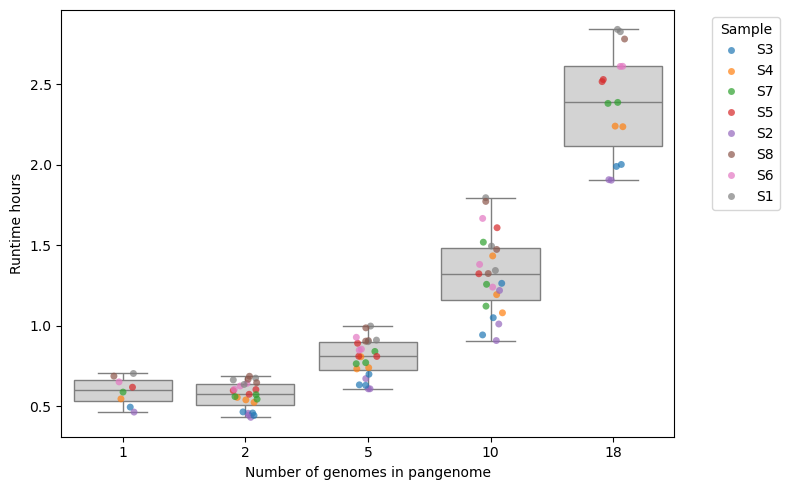

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Boxplot (no hue)
sns.boxplot(
    data=stats_linear_pang,
    x="n_genomes",
    y="runtime_hours",
    color="lightgray",
    fliersize=0
)

# Stripplot with sample-based colors
sns.stripplot(
    data=stats_linear_pang,
    x="n_genomes",
    y="runtime_hours",
    hue="sample",
    dodge=False,      # keep points centered per box
    alpha=0.7,
    size=5
)

plt.ylabel("Runtime hours")
plt.xlabel("Number of genomes in pangenome")

# Move legend outside (important, otherwise cluttered)
plt.legend(
    title="Sample",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig('runtime_hours_mapped.png')
plt.show()

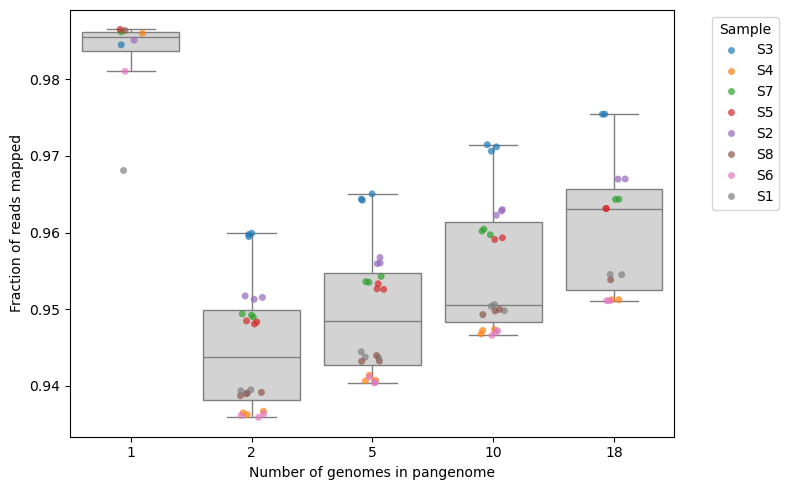

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Boxplot (no hue)
sns.boxplot(
    data=stats_linear_pang,
    x="n_genomes",
    y="pct_mapped",
    color="lightgray",
    fliersize=0
)

# Stripplot with sample-based colors
sns.stripplot(
    data=stats_linear_pang,
    x="n_genomes",
    y="pct_mapped",
    hue="sample",
    dodge=False,      # keep points centered per box
    alpha=0.7,
    size=5
)

plt.ylabel("Fraction of reads mapped")
plt.xlabel("Number of genomes in pangenome")

# Move legend outside (important, otherwise cluttered)
plt.legend(
    title="Sample",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig('fraction_of_reads_mapped.png')
plt.show()

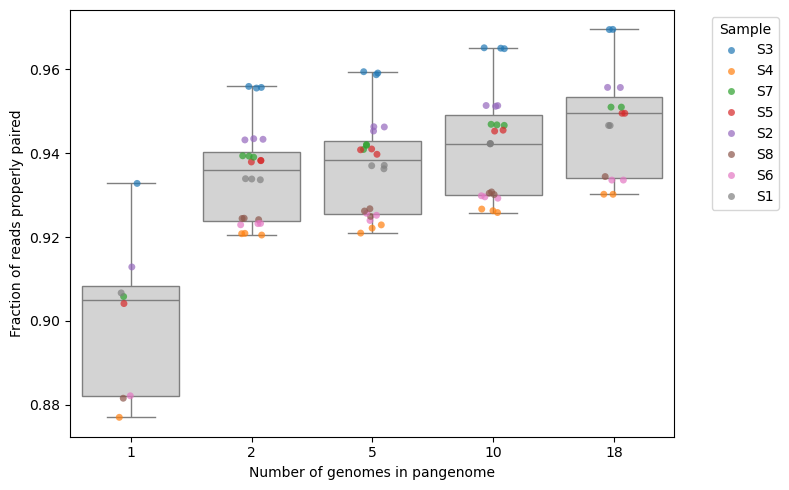

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Boxplot (no hue)
sns.boxplot(
    data=stats_linear_pang,
    x="n_genomes",
    y="pct_properly_paired",
    color="lightgray",
    fliersize=0
)

# Stripplot with sample-based colors
sns.stripplot(
    data=stats_linear_pang,
    x="n_genomes",
    y="pct_properly_paired",
    hue="sample",
    dodge=False,      # keep points centered per box
    alpha=0.7,
    size=5
)

plt.ylabel("Fraction of reads properly paired")
plt.xlabel("Number of genomes in pangenome")

# Move legend outside (important, otherwise cluttered)
plt.legend(
    title="Sample",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig('fraction_of_reads_prprl_paired.png')

plt.show()

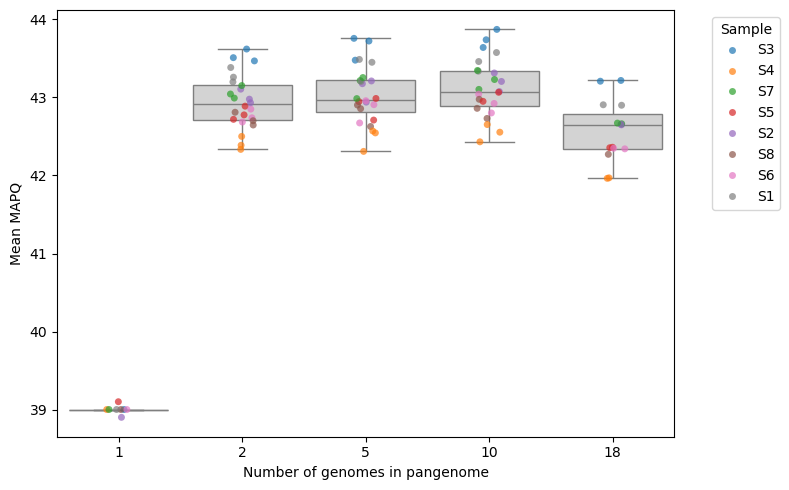

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Boxplot (no hue)
sns.boxplot(
    data=stats_linear_pang,
    x="n_genomes",
    y="mean_mapq",
    color="lightgray",
    fliersize=0
)

# Stripplot with sample-based colors
sns.stripplot(
    data=stats_linear_pang,
    x="n_genomes",
    y="mean_mapq",
    hue="sample",
    dodge=False,      # keep points centered per box
    alpha=0.7,
    size=5
)

plt.ylabel("Mean MAPQ")
plt.xlabel("Number of genomes in pangenome")

# Move legend outside (important, otherwise cluttered)
plt.legend(
    title="Sample",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig('mean_mapq.png')
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Boxplot (no hue)
sns.boxplot(
    data=stats_linear_pang,
    x="n_genomes",
    y="pct_mapped",
    color="lightgray",
    fliersize=0
)

# Stripplot with sample-based colors
sns.stripplot(
    data=stats_linear_pang,
    x="n_genomes",
    y="pct_mapped",
    hue="sample",
    dodge=False,      # keep points centered per box
    alpha=0.7,
    size=5
)

plt.ylabel("Fraction of reads mapped")
plt.xlabel("Number of genomes in pangenome")

# Move legend outside (important, otherwise cluttered)
plt.legend(
    title="Sample",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Boxplot (no hue)
sns.boxplot(
    data=stats_linear_pang,
    x="n_genomes",
    y="pct_mapped",
    color="lightgray",
    fliersize=0
)

# Stripplot with sample-based colors
sns.stripplot(
    data=stats_linear_pang,
    x="n_genomes",
    y="pct_mapped",
    hue="sample",
    dodge=False,      # keep points centered per box
    alpha=0.7,
    size=5
)

plt.ylabel("Fraction of reads mapped")
plt.xlabel("Number of genomes in pangenome")

# Move legend outside (important, otherwise cluttered)
plt.legend(
    title="Sample",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [40]:
78818808 - 579076

78239732

In [43]:
75725096 / 78818808

0.9607490638528814

In [42]:
76304172 / 78818808

0.9680959904899856

In [44]:
76304172 - 579076

75725096

In [45]:
78818808 - 2514636

76304172

In [ ]:
75725096 

In [24]:
df_map

,set,rep,sample,n_genomes,total_reads,mapped_reads,perfect_reads,gapless_reads,properly_paired,mean_mapq,median_mapq,mapping_time_sec,reads_per_sec,pct_mapped,pct_perfect,pct_gapless
0,set_02,rep1,S1,2,78239732,74019223,40995783,68445989,73591874,43.3844,60,67914.4,1152.040,0.946057,0.523977,0.874824
1,set_02,rep1,S2,2,50474180,48362310,26607382,44762431,47949728,43.1068,60,45674.2,1105.090,0.958159,0.527148,0.886838
2,set_02,rep1,S3,2,54308174,52448391,28827283,48431671,52234208,43.6210,60,46642.0,1164.360,0.965755,0.530809,0.891793
3,set_02,rep1,S4,2,58646998,55377031,30556174,51287491,54445038,42.5012,60,56449.0,1038.940,0.944243,0.521019,0.874512
4,set_02,rep1,S5,2,67755386,64753981,35913935,59890069,64061150,42.8888,60,61086.5,1109.170,0.955702,0.530053,0.883916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,set_18,rep1,S8,18,73950880,71164066,48633680,68808503,69717460,42.2715,60,307234.0,240.699,0.962315,0.657648,0.930462
79,set_30,rep1,S1,30,78239732,75230821,51774617,72762868,74608666,42.9079,60,312738.0,250.176,0.961542,0.661743,0.929999
80,set_30,rep1,S2,30,50474180,49157113,33514906,47559020,48583850,42.6579,60,209065.0,241.428,0.973906,0.664001,0.942245
81,set_30,rep1,S3,30,54308174,53318268,36539510,51552378,52995414,43.2201,60,219901.0,246.966,0.981772,0.672818,0.949256


In [38]:
67914/60

1131.9

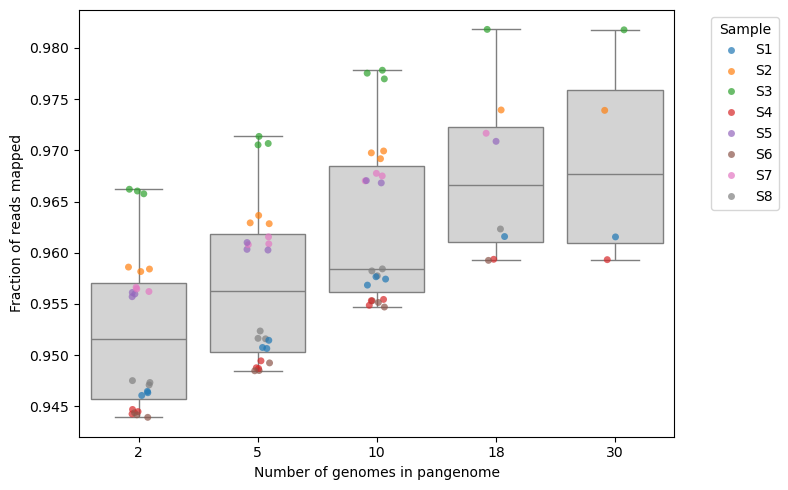

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Boxplot (no hue)
sns.boxplot(
    data=df_map,
    x="n_genomes",
    y="pct_mapped",
    color="lightgray",
    fliersize=0
)

# Stripplot with sample-based colors
sns.stripplot(
    data=df_map,
    x="n_genomes",
    y="pct_mapped",
    hue="sample",
    dodge=False,      # keep points centered per box
    alpha=0.7,
    size=5
)

plt.ylabel("Fraction of reads mapped")
plt.xlabel("Number of genomes in pangenome")

# Move legend outside (important, otherwise cluttered)
plt.legend(
    title="Sample",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [31]:
df_map

,set,rep,sample,n_genomes,total_reads,mapped_reads,perfect_reads,gapless_reads,properly_paired,mean_mapq,median_mapq,mapping_time_sec,reads_per_sec,pct_mapped,pct_perfect,pct_gapless
0,set_02,rep1,S1,2,78239732,74019223,40995783,68445989,73591874,43.3844,60,67914.4,1152.040,0.946057,0.523977,0.874824
1,set_02,rep1,S2,2,50474180,48362310,26607382,44762431,47949728,43.1068,60,45674.2,1105.090,0.958159,0.527148,0.886838
2,set_02,rep1,S3,2,54308174,52448391,28827283,48431671,52234208,43.6210,60,46642.0,1164.360,0.965755,0.530809,0.891793
3,set_02,rep1,S4,2,58646998,55377031,30556174,51287491,54445038,42.5012,60,56449.0,1038.940,0.944243,0.521019,0.874512
4,set_02,rep1,S5,2,67755386,64753981,35913935,59890069,64061150,42.8888,60,61086.5,1109.170,0.955702,0.530053,0.883916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,set_18,rep1,S8,18,73950880,71164066,48633680,68808503,69717460,42.2715,60,307234.0,240.699,0.962315,0.657648,0.930462
79,set_30,rep1,S1,30,78239732,75230821,51774617,72762868,74608666,42.9079,60,312738.0,250.176,0.961542,0.661743,0.929999
80,set_30,rep1,S2,30,50474180,49157113,33514906,47559020,48583850,42.6579,60,209065.0,241.428,0.973906,0.664001,0.942245
81,set_30,rep1,S3,30,54308174,53318268,36539510,51552378,52995414,43.2201,60,219901.0,246.966,0.981772,0.672818,0.949256


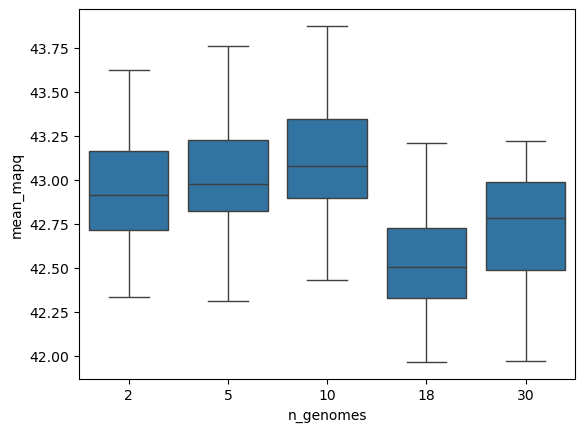

In [32]:
sns.boxplot(
    data=df_map,
    x="n_genomes",
    y="mean_mapq"
)
plt.show()


In [20]:
579076 + 78239732

78818808

In [ ]:
total_reads = 78818808

total_reads = 78239732

mapped_reads_l = 76304172
prop_mapped_reads_l = 71465104
mapped_reads_l/total_reads

prop_mapped_reads_l/total_reads

mapped_reads_p = 68497717
prop_mapped_reads_p = 68763068
mapped_reads_p/total_reads

prop_mapped_reads_p/total_reads

In [41]:
pip install pysam

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 23.1 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [42]:
import pysam

def count_perfect_linear(bam):
    bamf = pysam.AlignmentFile(bam)
    total = 0
    perfect = 0

    for read in bamf:
        if read.is_unmapped or read.is_secondary or read.is_supplementary:
            continue
        total += 1
        if read.get_tag("NM") == 0:
            perfect += 1

    return total, perfect


In [43]:
import pysam
from pathlib import Path

def count_perfect_linear(bam_path):
    bam = pysam.AlignmentFile(bam_path, "rb")

    total = 0
    perfect = 0

    for read in bam:
        # mirror vg "primary alignment" logic
        if read.is_unmapped:
            continue
        if read.is_secondary or read.is_supplementary:
            continue

        total += 1

        # NM tag = edit distance (mismatches + indels)
        try:
            if read.get_tag("NM") == 0:
                perfect += 1
        except KeyError:
            pass

    bam.close()
    return total, perfect


In [44]:
LINEAR_BASE = Path.home() / "scratch/pang/pang_experiment/linear_mapping/results"

rows_linear = []

for sample_dir in LINEAR_BASE.iterdir():
    if not sample_dir.is_dir():
        continue

    sample = sample_dir.name
    bam = sample_dir / f"{sample}.sorted.bam"
    flagstat = sample_dir / f"{sample}.flagstat.txt"

    if not bam.exists():
        continue

    total, perfect = count_perfect_linear(bam)

    rows_linear.append({
        "set": "TAIR10",
        "rep": "NA",
        "sample": sample,
        "n_genomes": 1,
        "total_reads": total,
        "perfect_reads": perfect,
        "pct_perfect": perfect / total,
        "method": "linear"
    })


In [45]:
rows_linear

[{'set': 'TAIR10',
  'rep': 'NA',
  'sample': 'S1',
  'n_genomes': 1,
  'total_reads': 75725096,
  'perfect_reads': 39712274,
  'pct_perfect': 0.5244268557942798,
  'method': 'linear'}]

In [46]:
df_map

,set,rep,sample,n_genomes,total_reads,mapped_reads,perfect_reads,gapless_reads,properly_paired,mean_mapq,median_mapq,mapping_time_sec,reads_per_sec,pct_mapped,pct_perfect,pct_gapless
0,set_02,rep1,S1,2,78239732,66923781,35556040,62066852,67270378,45.3854,60,63599.7,1230.190,0.855368,0.454450,0.793291
1,set_02,rep1,S2,2,50474180,43662311,23030370,40525283,43828552,45.0514,60,42436.4,1189.410,0.865043,0.456280,0.802891
2,set_02,rep1,S3,2,54308174,47391347,24989441,43893263,47670268,45.4686,60,44364.5,1224.140,0.872637,0.460141,0.808226
3,set_02,rep1,S4,2,58646998,49833789,26185683,46264439,49841474,44.6091,60,51376.7,1141.510,0.849724,0.446497,0.788863
4,set_02,rep1,S5,2,67755386,57913670,30386172,53670663,58134216,45.1005,60,57104.2,1186.520,0.854746,0.448469,0.792124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,set_30,rep3,S4,30,58646998,51151032,33052514,49461694,50714142,44.6581,60,90070.5,651.124,0.872185,0.563584,0.843380
124,set_30,rep3,S5,30,67755386,59491955,38403507,57467654,59361836,45.1639,60,82780.6,818.494,0.878040,0.566796,0.848164
125,set_30,rep3,S6,30,70309590,61212354,39416796,59143186,60875056,45.0650,60,106826.0,658.169,0.870612,0.560618,0.841182
126,set_30,rep3,S7,30,64976120,57112694,36998256,55188208,56988412,45.3796,60,96675.9,672.103,0.878980,0.569413,0.849361


In [5]:
samfile = pysam.AlignmentFile("your_bam", "rb")
for read in samfile.fetch():
     cig=read.cigarstring #for cigarstring
     aligned=read.get_aligned_pairs() # will give you the aligned pairs

NameError: name 'pysam' is not defined

In [2]:
import pysam

def bam_identity_stats(
    bam_path,
    min_identity=0.99,
    max_softclip_frac=0.01
):
    bam = pysam.AlignmentFile(bam_path, "rb")

    total_reads = 0
    aligned_reads = 0
    fully_mapped_reads = 0
    high_identity_reads = 0

    for read in bam.fetch(until_eof=True):
        total_reads += 1

        # Skip unmapped, secondary, supplementary alignments
        if read.is_unmapped or read.is_secondary or read.is_supplementary:
            continue

        aligned_reads += 1

        aligned_len = 0        # bases consuming the read
        softclip_len = 0       # soft-clipped read bases

        # Parse CIGAR
        for op, length in read.cigartuples:
            if op in {0, 7, 8, 1}:   # M, =, X, I  (consume read bases)
                aligned_len += length
            elif op == 4:            # S (soft clip)
                softclip_len += length
            # D (2) intentionally excluded — consumes reference only

        if aligned_len == 0:
            continue

        read_len = aligned_len + softclip_len

        # Fully-mapped criterion (allow small soft clipping)
        if softclip_len / read_len > max_softclip_frac:
            continue

        fully_mapped_reads += 1

        # Compute identity
        if not read.has_tag("NM"):
            continue

        nm = read.get_tag("NM")  # mismatches + indels
        identity = 1 - (nm / aligned_len)

        if identity >= min_identity:
            high_identity_reads += 1

    bam.close()

    return {
        "total_reads": total_reads,
        "aligned_reads": aligned_reads,
        "fully_mapped_reads": fully_mapped_reads,
        "high_identity_reads": high_identity_reads,
        "pct_high_identity": high_identity_reads / total_reads
    }


In [7]:
import pysam
import pandas as pd

def bam_identity_df(
    bam_path,
    max_softclip_frac=0.01
):
    bam = pysam.AlignmentFile(bam_path, "rb")
    rows = []

    for read in bam.fetch(until_eof=True):

        # Skip secondary / supplementary alignments
        if read.is_secondary or read.is_supplementary:
            continue

        read_name = read.query_name

        aligned = not read.is_unmapped
        identity = None
        aligned_len = 0          # read bases aligned
        softclip_len = 0

        if aligned and read.cigartuples is not None:

            for op, length in read.cigartuples:
                if op in {0, 7, 8, 1}:   # M, =, X, I  (consume read)
                    aligned_len += length
                elif op == 4:            # S (soft clip)
                    softclip_len += length
                # D (2) intentionally excluded — reference-only

            read_len = aligned_len + softclip_len

            # Compute identity only if meaningful
            if aligned_len > 0 and read.has_tag("NM"):
                nm = read.get_tag("NM")
                identity = 1 - (nm / aligned_len)

            # Apply soft-clip filter (optional, but recorded)
            softclip_frac = (
                softclip_len / read_len if read_len > 0 else None
            )
        else:
            softclip_frac = None

        rows.append({
            "read": read_name,
            "aligned": aligned,
            "identity": identity,
            "aligned_len": aligned_len,
            "softclip_frac": softclip_frac,
            "mapping_quality": read.mapping_quality
        })

    bam.close()
    return pd.DataFrame(rows)


In [ ]:
stats_linear_full = bam_identity_df(
    "/home/tbellagio/scratch/pang/pang_experiment/linear_mapping/results/S1/S1.sorted.bam"
)


In [ ]:
stats_linear_full

In [ ]:
### based on the fastq files there are 78239732 reads 

In [ ]:
stats_linear = bam_identity_stats(
    "/home/tbellagio/scratch/pang/pang_experiment/linear_mapping/results/S1/S1.sorted.bam"
)

stats_linear


In [3]:
stats_linear = bam_identity_stats(
    "/home/tbellagio/scratch/pang/pang_experiment/linear_mapping/results/S1/S1.sorted.bam"
)

stats_linear

{'total_reads': 78960669,
 'aligned_reads': 69200455,
 'fully_mapped_reads': 61792509,
 'high_identity_reads': 42702692,
 'pct_high_identity': 0.5408096529678592}

In [2]:
stats_linear = bam_identity_stats(
    "/home/tbellagio/scratch/pang/pang_experiment/linear_mapping/results/S1/S1.sorted.bam"
)

stats_linear


{'total_reads': 78818808,
 'aligned_reads': 75725096,
 'fully_mapped_reads': 70085283,
 'high_identity_reads': 49040312,
 'pct_high_identity': 0.6221904802214213}

In [3]:
stats_linear

{'total_reads': 78818808,
 'aligned_reads': 75725096,
 'fully_mapped_reads': 70085283,
 'high_identity_reads': 49040312,
 'pct_high_identity': 0.6221904802214213}

In [ ]:
49040312/78818808

In [ ]:
56607553

In [ ]:
75725096

In [50]:
stats_linear

{'total_reads': 78818808,
 'aligned_reads': 75725096,
 'fully_mapped_reads': 70085315,
 'high_identity_reads': 49041170,
 'pct_high_identity': 0.622201365948087}

In [66]:
75725096/78818808

78239733

0.9607490638528814

In [79]:
29474015/78818808

0.3739464697309302

In [ ]:
78239732

In [68]:
identity = pd.read_csv('/home/tbellagio/scratch/pang/pang_experiment/pangenomes/set_02_rep1/mapping/seedmix/S1/S1.identity.tsv',
                      sep = '\t')

In [96]:
identity

,#name,identity,mapping_quality,length,softclip_start,softclip_end
0,ST-J00101:102:HVW7TBBXX:3:1101:3062:1877,0.0,0,57,0,0
1,ST-J00101:102:HVW7TBBXX:3:1101:3062:1877,0.0,0,149,0,0
2,ST-J00101:102:HVW7TBBXX:3:1101:27022:1894,1.0,60,150,75,0
3,ST-J00101:102:HVW7TBBXX:3:1101:27022:1894,1.0,60,59,0,0
4,ST-J00101:102:HVW7TBBXX:3:1101:22394:3055,1.0,0,150,0,0
...,...,...,...,...,...,...
78239727,ST-J00101:102:HVW7TBBXX:3:2228:5386:48913,1.0,0,80,0,0
78239728,ST-J00101:102:HVW7TBBXX:3:2228:5792:48913,1.0,60,150,0,0
78239729,ST-J00101:102:HVW7TBBXX:3:2228:5792:48913,1.0,60,136,0,0
78239730,ST-J00101:102:HVW7TBBXX:3:2228:5994:48913,0.0,0,150,0,0


In [86]:
len(identity)

78239732

In [71]:
identity_mapped = identity[identity["mapping_quality"] > 0]

In [85]:
56607553/78239732

0.7235141475177854

In [72]:
identity_mapped

,#name,identity,mapping_quality,length,softclip_start,softclip_end
2,ST-J00101:102:HVW7TBBXX:3:1101:27022:1894,1.000000,60,150,75,0
3,ST-J00101:102:HVW7TBBXX:3:1101:27022:1894,1.000000,60,59,0,0
6,ST-J00101:102:HVW7TBBXX:3:1101:27428:1894,1.000000,27,150,0,109
7,ST-J00101:102:HVW7TBBXX:3:1101:3082:1877,0.993333,60,150,0,0
9,ST-J00101:102:HVW7TBBXX:3:1101:3082:1877,1.000000,60,150,0,0
...,...,...,...,...,...,...
78239719,ST-J00101:102:HVW7TBBXX:3:2228:4493:48913,1.000000,60,49,0,0
78239722,ST-J00101:102:HVW7TBBXX:3:2228:4553:48913,1.000000,60,150,0,0
78239723,ST-J00101:102:HVW7TBBXX:3:2228:4553:48913,1.000000,60,148,0,0
78239728,ST-J00101:102:HVW7TBBXX:3:2228:5792:48913,1.000000,60,150,0,0


In [95]:
mapped_reads = identity.groupby("#name")["mapping_quality"].max()

In [97]:
mapped_reads

#name
ST-J00101:102:HVW7TBBXX:3:1101:10003:10774     1
ST-J00101:102:HVW7TBBXX:3:1101:10003:11091    60
ST-J00101:102:HVW7TBBXX:3:1101:10003:11337     0
ST-J00101:102:HVW7TBBXX:3:1101:10003:11513    60
ST-J00101:102:HVW7TBBXX:3:1101:10003:11794    60
                                              ..
ST-J00101:102:HVW7TBBXX:3:2228:9993:8260      60
ST-J00101:102:HVW7TBBXX:3:2228:9993:8576       0
ST-J00101:102:HVW7TBBXX:3:2228:9993:9666       0
ST-J00101:102:HVW7TBBXX:3:2228:9993:9913      60
ST-J00101:102:HVW7TBBXX:3:2228:9993:9983      60
Name: mapping_quality, Length: 39119866, dtype: int64

In [98]:
39119866/78239732

0.5

In [92]:
mapped_reads.mean()

0.7534283220704283

In [87]:
66923781/78239732

0.8553682290220523

In [76]:
best = (
    identity_mapped.groupby("#name", as_index=False)
      .agg(
          max_identity=("identity", "max"),
          max_mapq=("mapping_quality", "max")
      )
)


In [77]:
best

,#name,max_identity,max_mapq
0,ST-J00101:102:HVW7TBBXX:3:1101:10003:10774,0.993333,1
1,ST-J00101:102:HVW7TBBXX:3:1101:10003:11091,1.000000,60
2,ST-J00101:102:HVW7TBBXX:3:1101:10003:11513,1.000000,60
3,ST-J00101:102:HVW7TBBXX:3:1101:10003:11794,0.993333,60
4,ST-J00101:102:HVW7TBBXX:3:1101:10003:12181,1.000000,60
...,...,...,...
29474010,ST-J00101:102:HVW7TBBXX:3:2228:9993:6747,1.000000,60
29474011,ST-J00101:102:HVW7TBBXX:3:2228:9993:7099,0.926667,1
29474012,ST-J00101:102:HVW7TBBXX:3:2228:9993:8260,1.000000,60
29474013,ST-J00101:102:HVW7TBBXX:3:2228:9993:9913,1.000000,60


In [78]:
pct_id99 = (best["max_identity"] >= 0.99).mean()
pct_id99

0.8693801981168836